# Tutorial: Online Conformal Prediction with `online-cp`

This tutorial teaches conformal prediction through the lens of **questions you'd naturally ask** when building a prediction system:

1. [How uncertain should I be?](#1.-How-uncertain-should-I-be?) — Regression with Ridge, Kernel Ridge, and Lasso
2. [What about classification?](#2.-What-about-classification?) — Prediction sets with KNN and SVM, plus calibrated probabilities with Venn-Abers
3. [Is it fair to everyone?](#3.-Is-it-fair-to-everyone?) — Mondrian CP for group-conditional coverage
4. [What's the full picture?](#4.-What's-the-full-picture?) — Conformal Predictive Systems
5. [Can I trust my data?](#5.-Can-I-trust-my-data?) — Martingales for detecting distribution shift
6. [Putting it into production](#6.-Putting-it-into-production) — Streaming evaluation and plotting

**Prerequisites**: Basic familiarity with supervised learning. No conformal prediction background needed.

**Core guarantee**: Given exchangeable data and significance level $\varepsilon$, a conformal predictor produces sets $\Gamma^\varepsilon$ satisfying $\mathbb{P}(y_{\text{new}} \in \Gamma^\varepsilon) \geq 1 - \varepsilon$ — with no distributional assumptions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_wine, load_breast_cancer

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100
rng = np.random.default_rng(42)

---
## 1. How uncertain should I be?

You have a regression model. For each prediction, you want an interval $[l, u]$ that **provably** contains the true value at least $1 - \varepsilon$ of the time — regardless of the data distribution.

### 1.1 Ridge regression on real data

We'll use the California Housing dataset. The data must be **randomly permuted** to satisfy the exchangeability assumption (the raw data is geographically ordered).

In [2]:
from online_cp import ConformalRidgeRegressor, ErrorRate, IntervalWidth, WinklerScore
from online_cp.evaluate import progressive_val
from online_cp.plotting import plot_coverage, plot_intervals

# Load and randomly permute for exchangeability
housing = fetch_california_housing()
perm = rng.permutation(len(housing.target))
X_h, y_h = housing.data[perm[:600]], housing.target[perm[:600]]

# Create model, seed with 50 initial examples
model = ConformalRidgeRegressor(a=1.0)
model.learn_initial_training_set(X_h[:50], y_h[:50])

# Test-then-train on the remaining 550 points
metric = ErrorRate() + IntervalWidth() + WinklerScore()
progressive_val(model, X_h[50:], y_h[50:], epsilon=0.1, metric=metric)

print(metric)

ErrorRate: 0.1218
IntervalWidth: 2.2805
WinklerScore: 3.1423


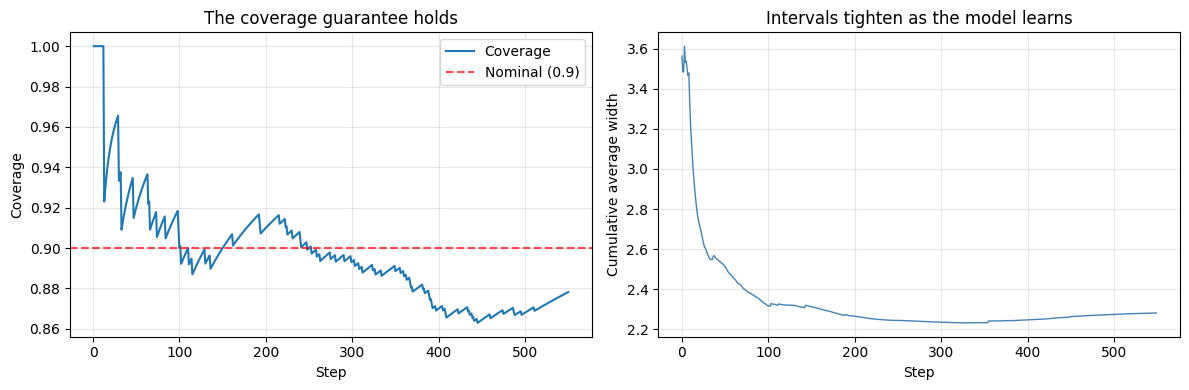

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# The guarantee in action: coverage converges to 1 - ε
plot_coverage(metric["ErrorRate"], nominal=0.9, ax=axes[0])
axes[0].set_title("The coverage guarantee holds")

# Intervals tighten as the model learns more
widths = metric["IntervalWidth"].cumulative_mean()
axes[1].plot(widths, color="steelblue", linewidth=1)
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Cumulative average width")
axes[1].set_title("Intervals tighten as the model learns")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The left plot shows the key result: the empirical coverage converges to (at least) the guaranteed $1 - \varepsilon = 0.9$ level. The right plot shows that intervals become tighter over time as the model has more data to calibrate against.

### 1.2 Kernel Ridge — nonlinear data

When the relationship between features and response is nonlinear, a linear model produces unnecessarily wide intervals. `KernelConformalRidgeRegressor` uses kernel methods to capture nonlinear structure:

In [4]:
from online_cp import KernelConformalRidgeRegressor, GaussianKernel

# Synthetic nonlinear data
N_nl = 500
X_nl = rng.uniform(-3, 3, (N_nl, 2))
y_nl = np.sin(X_nl[:, 0]) + 0.5 * X_nl[:, 1]**2 + rng.normal(0, 0.3, N_nl)

# Compare linear vs kernel
linear = ConformalRidgeRegressor(a=1.0)
linear.learn_initial_training_set(X_nl[:50], y_nl[:50])
m_linear = ErrorRate() + IntervalWidth()
progressive_val(linear, X_nl[50:], y_nl[50:], epsilon=0.1, metric=m_linear)

kernel_model = KernelConformalRidgeRegressor(kernel=GaussianKernel(sigma=1.5), a=0.5)
kernel_model.learn_initial_training_set(X_nl[:50], y_nl[:50])
m_kernel = ErrorRate() + IntervalWidth()
progressive_val(kernel_model, X_nl[50:], y_nl[50:], epsilon=0.1, metric=m_kernel)

print(f"Linear ridge:  {m_linear}")
print(f"Kernel ridge:  {m_kernel}")
print(f"\n→ Both satisfy the coverage guarantee, but the kernel model is more efficient.")

Linear ridge:  ErrorRate: 0.1044
IntervalWidth: 4.6912
Kernel ridge:  ErrorRate: 0.1156
IntervalWidth: 1.3424

→ Both satisfy the coverage guarantee, but the kernel model is more efficient.


### 1.3 Lasso — high-dimensional sparse data

`ConformalLassoRegressor` implements *exact* online conformal prediction with L1 regularisation via a piecewise-linear homotopy algorithm (Lei, 2018). This is the package's most technically sophisticated regressor — ideal when you have many features but suspect only a few are relevant.

In [5]:
from online_cp import ConformalLassoRegressor

# High-dimensional sparse problem: 30 features, only 4 matter
N_lasso, p = 150, 30
X_lasso = rng.normal(size=(N_lasso, p))
beta_true = np.zeros(p)
beta_true[:4] = [3.0, -2.0, 1.5, -1.0]
y_lasso = X_lasso @ beta_true + rng.normal(0, 0.5, N_lasso)

# Conformal Lasso with λ = 0.5
lasso = ConformalLassoRegressor(lam=0.5, rnd_state=42)
lasso.learn_initial_training_set(X_lasso[:50], y_lasso[:50])

m_lasso = ErrorRate() + IntervalWidth()
progressive_val(lasso, X_lasso[50:], y_lasso[50:], epsilon=0.1, metric=m_lasso)

print(f"Lasso (p={p}, 4 active): {m_lasso}")

# Automatic λ tuning via cross-validation
lasso_auto = ConformalLassoRegressor(lam=1.0, autotune=True, n_folds=5, rnd_state=0)
lasso_auto.learn_initial_training_set(X_lasso[:50], y_lasso[:50])
print(f"\nAuto-tuned λ = {lasso_auto.lam:.4f}")

Lasso (p=30, 4 active): ErrorRate: 0.1000
IntervalWidth: 1.9592

Auto-tuned λ = 1.8261


### 1.4 P-values — the building block

Under the hood, conformal prediction works by computing **p-values** — measures of how well a candidate label conforms to the training data. Under exchangeability, these p-values are exactly uniform on $[0, 1]$:

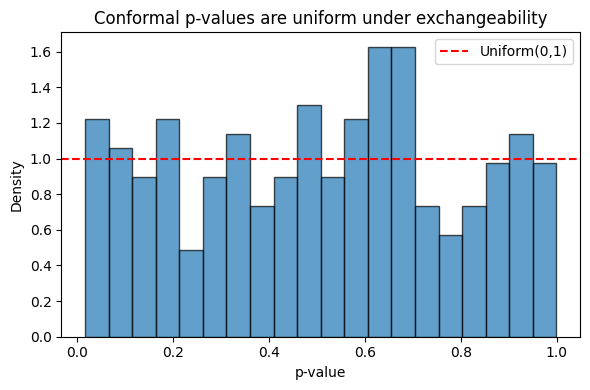

In [6]:
# Collect conformal p-values
cp_pv = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_pv.learn_initial_training_set(X_h[:50], y_h[:50])

p_values = []
for i in range(50, 300):
    p_values.append(cp_pv.compute_p_value(X_h[i], y_h[i]))
    cp_pv.learn_one(X_h[i], y_h[i])

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(p_values, bins=20, density=True, alpha=0.7, edgecolor="black")
ax.axhline(1.0, color="red", linestyle="--", label="Uniform(0,1)")
ax.set_xlabel("p-value")
ax.set_ylabel("Density")
ax.set_title("Conformal p-values are uniform under exchangeability")
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. What about classification?

For classification, conformal prediction produces **prediction sets** — subsets of labels guaranteed to contain the true class. The interpretation:
- **Singleton** `{1}` → confident prediction
- **Multiple** `{0, 2}` → uncertain between those classes
- **Empty** `{}` → all labels look unusual (happens at most $\varepsilon$ of the time)

### 2.1 KNN classifier on Wine data

In [7]:
from online_cp import ConformalNearestNeighboursClassifier, SetSize

# Wine dataset (3 classes, 13 features)
wine = load_wine()
perm_w = rng.permutation(len(wine.target))
X_w, y_w = wine.data[perm_w], wine.target[perm_w]
labels = np.unique(y_w)

knn = ConformalNearestNeighboursClassifier(k=5, label_space=labels, rnd_state=42)
knn.learn_initial_training_set(X_w[:30], y_w[:30])

metric_knn = ErrorRate() + SetSize()
progressive_val(knn, X_w[30:], y_w[30:], epsilon=0.1, metric=metric_knn)

sizes = np.array(metric_knn["SetSize"].values)
print(f"Error rate: {metric_knn['ErrorRate'].get():.3f} (target ≤ 0.1)")
print(f"Average set size: {metric_knn['SetSize'].get():.2f}")
print(f"Singletons (confident): {np.mean(sizes == 1):.0%}")
print(f"Empty sets (anomalous): {np.mean(sizes == 0):.0%}")

Error rate: 0.101 (target ≤ 0.1)
Average set size: 1.50
Singletons (confident): 52%
Empty sets (anomalous): 1%


### 2.2 SVM classifier

`ConformalSupportVectorMachine` uses an RBF kernel and tends to produce **smaller** prediction sets (higher efficiency) at the cost of more computation:

In [8]:
from online_cp import ConformalSupportVectorMachine

svm = ConformalSupportVectorMachine(
    kernel="rbf", sigma=1.0, C=10.0, label_space=labels, rnd_state=42
)
svm.learn_initial_training_set(X_w[:30], y_w[:30])

metric_svm = ErrorRate() + SetSize()
progressive_val(svm, X_w[30:], y_w[30:], epsilon=0.1, metric=metric_svm)

print(f"KNN — error: {metric_knn['ErrorRate'].get():.3f}, avg set size: {metric_knn['SetSize'].get():.2f}")
print(f"SVM — error: {metric_svm['ErrorRate'].get():.3f}, avg set size: {metric_svm['SetSize'].get():.2f}")
print(f"\n→ Both satisfy the coverage guarantee. The nonconformity measure determines efficiency.")

KNN — error: 0.101, avg set size: 1.50
SVM — error: 0.088, avg set size: 2.61

→ Both satisfy the coverage guarantee. The nonconformity measure determines efficiency.


### 2.3 Multi-level predictions

Like a zoom lens — get predictions at multiple confidence levels in a single call:

In [9]:
# Multi-level prediction
knn2 = ConformalNearestNeighboursClassifier(k=5, label_space=labels, rnd_state=42)
knn2.learn_initial_training_set(X_w[:80], y_w[:80])

Gamma = knn2.predict(X_w[80], epsilon=[0.01, 0.05, 0.1, 0.2, 0.5])

print(f"True label: {y_w[80]}\n")
for eps, pred_set in Gamma:
    print(f"  ε={eps:.2f}: {pred_set.elements}  (size {len(pred_set)})")

print(f"\nCoverage check: {Gamma.coverage(y_w[80])}")

True label: 0

  ε=0.01: [0]  (size 1)
  ε=0.05: [0]  (size 1)
  ε=0.10: [0]  (size 1)
  ε=0.20: [0]  (size 1)
  ε=0.50: [0]  (size 1)

Coverage check: {0.01: True, 0.05: True, 0.1: True, 0.2: True, 0.5: True}


### 2.4 Venn-Abers — calibrated probabilities

Conformal predictors output **sets**, not probabilities. But sometimes you want a calibrated $P(y=1)$. The **Venn-Abers predictor** (Algorithm 6.1, ALRW2 §6.4) gives you a **multiprobability pair** $(p^0, p^1)$:

- $p^0$: calibrated probability assuming the true label is 0
- $p^1$: calibrated probability assuming the true label is 1

This pair IS the prediction — it is not an interval or a point estimate. When you need a single probability for decision-making, use the utility functions `log_loss_point(p0, p1)` or `brier_point(p0, p1)` (ALRW2 §6.4).

This is the **full/transductive** variant — no data splitting. The scorer is retrained on the augmented dataset for each hypothesis, then isotonically calibrated via the pool-adjacent-violators algorithm (PAVA).

In [10]:
from online_cp import VennAbersPredictor, log_loss_point
from sklearn.metrics import log_loss
from sklearn.preprocessing import StandardScaler

# Breast cancer dataset — binary classification
bc = load_breast_cancer()
perm_bc = rng.permutation(len(bc.target))
X_bc, y_bc = bc.data[perm_bc], bc.target[perm_bc]
scaler = StandardScaler()
X_bc_scaled = scaler.fit_transform(X_bc)

# Ridge-scored Venn-Abers predictor
vap = VennAbersPredictor(scorer="knn", k=1)
vap.learn_initial_training_set(X_bc_scaled[:50], y_bc[:50])

# Stream predictions — collect the multiprobability pairs
p0s, p1s = [], []
labels_test = []
for i in range(50, 200):
    pred = vap.predict(X_bc_scaled[i])
    p0s.append(pred.p0)
    p1s.append(pred.p1)
    labels_test.append(y_bc[i])
    vap.learn_one(X_bc_scaled[i], y_bc[i])

p0s = np.array(p0s)
p1s = np.array(p1s)
labels_test = np.array(labels_test)

# For evaluation, merge pairs into single probabilities using log_loss_point
merged = np.array([log_loss_point(p0, p1) for p0, p1 in zip(p0s, p1s)])

print(f"Mean merged P(y=1) for true 1s: {merged[labels_test == 1].mean():.3f}")
print(f"Mean merged P(y=1) for true 0s: {merged[labels_test == 0].mean():.3f}")
print(f"\nAccuracy (threshold 0.5): {np.mean((merged > 0.5) == labels_test):.1%}")
print(f"Log loss: {log_loss(labels_test, merged):.3f}")

Mean merged P(y=1) for true 1s: 0.888
Mean merged P(y=1) for true 0s: 0.208

Accuracy (threshold 0.5): 94.0%
Log loss: 0.203


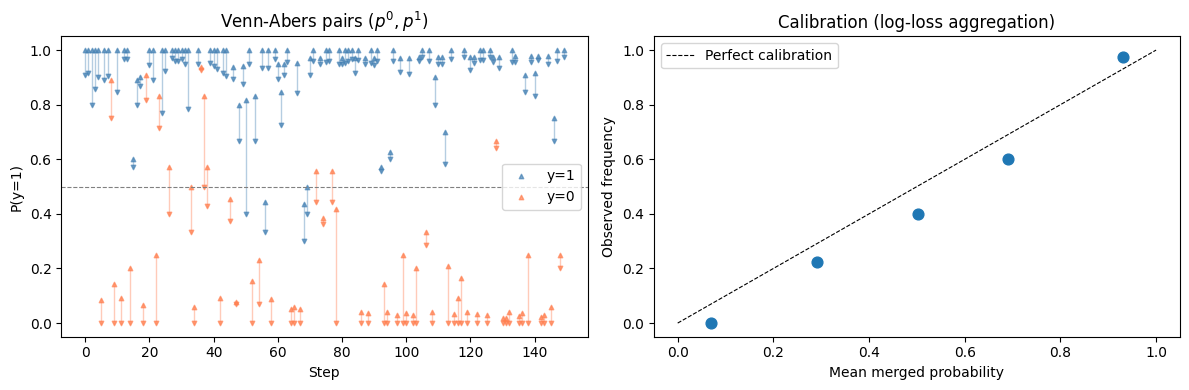

In [11]:
# Visualise the multiprobability pairs
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: multiprobability pairs over time, colored by true label
ax = axes[0]
for label, color, name in [(1, 'steelblue', 'y=1'), (0, 'coral', 'y=0')]:
    mask = labels_test == label
    idx = np.where(mask)[0]
    # Show the pair as a vertical bar from p0 to p1
    for j in idx:
        ax.plot([j, j], [p0s[j], p1s[j]], color=color, alpha=0.4, lw=1)
    ax.scatter(idx, p1s[mask], c=color, s=10, alpha=0.7, label=name, marker='^')
    ax.scatter(idx, p0s[mask], c=color, s=10, alpha=0.7, marker='v')
ax.axhline(0.5, color='gray', ls='--', lw=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('P(y=1)')
ax.set_title('Venn-Abers pairs $(p^0, p^1)$')
ax.legend()

# Right: calibration of merged predictions (for evaluation only)
ax = axes[1]
n_bins = 5
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_means, bin_freqs = [], []
for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):
    mask = (merged >= lo) & (merged < hi)
    if mask.sum() > 0:
        bin_means.append(merged[mask].mean())
        bin_freqs.append(labels_test[mask].mean())
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Perfect calibration')
ax.scatter(bin_means, bin_freqs, s=60, zorder=5)
ax.set_xlabel('Mean merged probability')
ax.set_ylabel('Observed frequency')
ax.set_title('Calibration (log-loss aggregation)')
ax.legend()
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

The Venn-Abers predictor also supports **k-NN scoring** and **SVM scoring** — useful when the decision boundary is nonlinear:

```python
vap_knn = VennAbersPredictor(scorer="knn", k=5)
vap_svm = VennAbersPredictor(scorer="svm", kernel="rbf", sigma=1.0, C=10.0)
```

The key property: the multiprobability pair $(p^0, p^1)$ is **automatically well-calibrated** — no post-hoc recalibration needed. When you need a single probability for decision-making, use `log_loss_point(p0, p1)` (minimises log loss) or `brier_point(p0, p1)` (minimises Brier loss).

---
## 3. Is it fair to everyone?

Standard conformal prediction guarantees **marginal** coverage — on average across all examples. But what if some subgroups are systematically undercovered?

**Mondrian conformal prediction** guarantees coverage *within each group*:

$$\mathbb{P}(y \in \Gamma^\varepsilon \mid \text{group} = k) \geq 1 - \varepsilon \quad \text{for each } k$$

The key: use a single pooled model but filter the calibration set to same-group examples.

In [12]:
from online_cp import MondrianConformalClassifier

# Breast Cancer dataset — split into groups by mean radius
bc = load_breast_cancer()
perm_bc = rng.permutation(len(bc.target))
X_bc, y_bc = bc.data[perm_bc], bc.target[perm_bc]
labels_bc = np.array([0, 1])

# Group: "large" vs "small" tumours (by median of mean radius, feature 0)
median_radius = np.median(X_bc[:, 0])
category_fn = lambda x: "large" if x[0] > median_radius else "small"

# Standard (marginal) conformal classifier
std_clf = ConformalNearestNeighboursClassifier(k=5, label_space=labels_bc, rnd_state=0)
std_clf.learn_initial_training_set(X_bc[:50], y_bc[:50])

# Mondrian (group-conditional) conformal classifier
mond_clf = MondrianConformalClassifier(
    base_model=ConformalNearestNeighboursClassifier(k=5, label_space=labels_bc),
    category_fn=category_fn,
)
mond_clf.learn_initial_training_set(X_bc[:50], y_bc[:50])

# Evaluate both, tracking errors by group
errors_std = {"large": [], "small": []}
errors_mond = {"large": [], "small": []}

for i in range(50, len(X_bc)):
    cat = category_fn(X_bc[i])

    pred_std = std_clf.predict(X_bc[i], epsilon=0.1)
    errors_std[cat].append(y_bc[i] not in pred_std)
    std_clf.learn_one(X_bc[i], y_bc[i])

    pred_mond = mond_clf.predict(X_bc[i], epsilon=0.1)
    errors_mond[cat].append(y_bc[i] not in pred_mond)
    mond_clf.learn_one(X_bc[i], y_bc[i])

print("Per-group error rates (target ≤ 0.1):")
print(f"{'Method':<12} {'Large':>8} {'Small':>8}")
print(f"{'Standard':<12} {np.mean(errors_std['large']):>8.3f} {np.mean(errors_std['small']):>8.3f}")
print(f"{'Mondrian':<12} {np.mean(errors_mond['large']):>8.3f} {np.mean(errors_mond['small']):>8.3f}")

Per-group error rates (target ≤ 0.1):
Method          Large    Small
Standard        0.187    0.058
Mondrian        0.107    0.105


The standard method satisfies *marginal* coverage but may undercovering one group. Mondrian CP guarantees each group gets at least $1 - \varepsilon$ coverage independently.

> **Note**: `MondrianConformalRegressor` works the same way for regression tasks.

---
## 4. What's the full picture?

Conformal Predictive Systems (CPS) go beyond intervals — they produce full **predictive distributions**. A conformal predictive distribution (CPD) assigns to each candidate value $y$ a probability $Q(y) \in [0, 1]$, and you can extract intervals at *any* level from it.

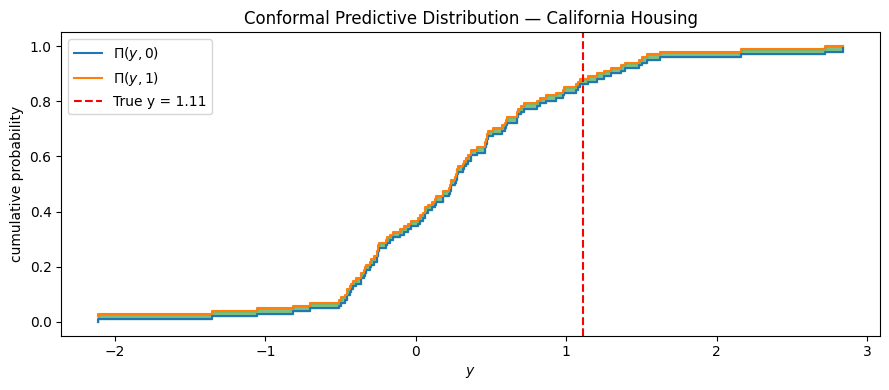

In [13]:
from online_cp import RidgePredictionMachine

# Use California Housing data
cps = RidgePredictionMachine(a=1.0)
cps.learn_initial_training_set(X_h[:100], y_h[:100])

# Get a conformal predictive distribution for one point
cpd = cps.predict_cpd(X_h[100])

fig = cpd.plot()
fig.set_size_inches(9, 4)
ax = fig.axes[0]
ax.axvline(y_h[100], color="red", linestyle="--", linewidth=1.5,
           label=f"True y = {y_h[100]:.2f}")
ax.legend()
ax.set_title("Conformal Predictive Distribution — California Housing")
fig.tight_layout()
fig

In [14]:
# Extract intervals at different levels from the same CPD
tau = rng.uniform()  # random tie-breaking
print(f"Intervals from one CPD (τ = {tau:.3f}):\n")
for eps in [0.01, 0.05, 0.1, 0.2]:
    iv = cpd.predict_set(tau, epsilon=eps)
    hit = "✓" if y_h[100] in iv else "✗"
    print(f"  ε={eps:.2f}: [{iv.lower:.2f}, {iv.upper:.2f}]  width={iv.width():.2f}  {hit}")

# The CPD evaluated at the true y is itself a p-value
p = cpd(y_h[100], tau)
print(f"\nCPD(y_true) = {p:.3f}  (a valid conformal p-value)")

Intervals from one CPD (τ = 0.212):

  ε=0.01: [-2.11, inf]  width=inf  ✓
  ε=0.05: [-1.05, 2.72]  width=3.77  ✓
  ε=0.10: [-0.70, 1.54]  width=2.24  ✓
  ε=0.20: [-0.46, 1.30]  width=1.75  ✓

CPD(y_true) = 0.863  (a valid conformal p-value)


Other CPS variants: `KernelRidgePredictionMachine` (nonlinear), `NearestNeighboursPredictionMachine` (nonparametric), `DempsterHillConformalPredictiveSystem` (distribution-free).

---
## 5. Can I trust my data?

Conformal prediction assumes exchangeability. But what if the data distribution **shifts** over time? Conformal test martingales let you detect this *online*.

The idea: if p-values are truly uniform (exchangeability holds), a martingale $M_n$ satisfies $\mathbb{E}[M_n] \leq 1$. If the martingale grows large, it's evidence against exchangeability.

### 5.1 Exchangeable data — martingale stays flat

In [15]:
from online_cp import SimpleJumper
from online_cp.plotting import plot_martingale

# Exchangeable data: the California Housing data (already permuted)
cp_exch = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_exch.learn_initial_training_set(X_h[:50], y_h[:50])

mart_exch = SimpleJumper()
for i in range(50, 400):
    p = cp_exch.compute_p_value(X_h[i], y_h[i])
    mart_exch.update(p)
    cp_exch.learn_one(X_h[i], y_h[i])

print(f"Final martingale value: {mart_exch.M:.2f}  (stays small → data looks exchangeable)")

Final martingale value: 0.08  (stays small → data looks exchangeable)


### 5.2 Distribution shift — martingale explodes

Now let's simulate a sensor that drifts: the first 150 readings follow one distribution, then the mean shifts by 3.

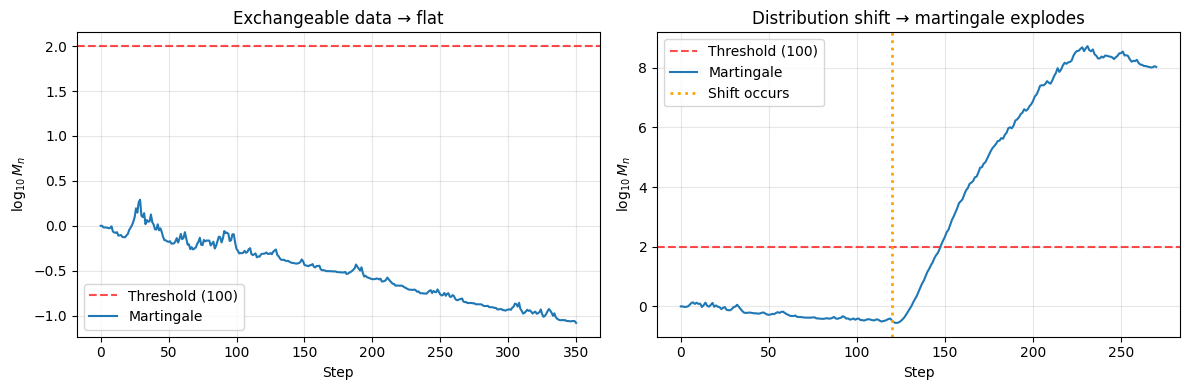


Max log-martingale after shift: 20.1
→ Strong evidence against exchangeability!


In [16]:
# Synthetic data with a shift at t=150
N_shift = 300
rng_s = np.random.default_rng(456)
X_s = rng_s.normal(size=(N_shift, 3))
y_s = np.empty(N_shift)
y_s[:150] = X_s[:150] @ [1, -1, 0.5] + rng_s.normal(0, 0.3, 150)
y_s[150:] = X_s[150:] @ [1, -1, 0.5] + 3.0 + rng_s.normal(0, 0.3, 150)  # mean shift!

cp_s = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_s.learn_initial_training_set(X_s[:30], y_s[:30])

mart_shift = SimpleJumper()
for i in range(30, N_shift):
    p = cp_s.compute_p_value(X_s[i], y_s[i])
    mart_shift.update(p)
    cp_s.learn_one(X_s[i], y_s[i])

# Plot both martingales side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_martingale(mart_exch, ax=axes[0])
axes[0].set_title("Exchangeable data → flat")

plot_martingale(mart_shift, ax=axes[1])
axes[1].axvline(150 - 30, color="orange", linestyle=":", linewidth=2, label="Shift occurs")
axes[1].legend()
axes[1].set_title("Distribution shift → martingale explodes")

plt.tight_layout()
plt.show()

print(f"\nMax log-martingale after shift: {max(mart_shift.log_martingale_values):.1f}")
print(f"→ Strong evidence against exchangeability!")

### 5.3 Ville's inequality — simple threshold test

The simplest way to turn a martingale into a hypothesis test: reject exchangeability the first time $M_n$ exceeds a threshold $c$. By **Ville's inequality**, $P(\exists n: M_n \geq c) \leq 1/c$, so setting $c = 20$ gives a test at the 5% significance level.

`VilleWrapper` wraps any base martingale and tracks the running maximum:

In [17]:
from online_cp import SimpleJumper, VilleWrapper

# Wrap a SimpleJumper with Ville's inequality at threshold=20 (5% significance)
ville = VilleWrapper(SimpleJumper(), threshold=20)

# Feed the same shifted data from Section 5.2
cp_v = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_v.learn_initial_training_set(X_s[:30], y_s[:30])

for i in range(30, N_shift):
    p = cp_v.compute_p_value(X_s[i], y_s[i])
    ville.update(p)
    cp_v.learn_one(X_s[i], y_s[i])
    if ville.rejected:
        print(f"✓ Exchangeability rejected at observation {i} (threshold={ville.threshold})")
        break

# With a stricter threshold (1% significance):
ville_strict = VilleWrapper(SimpleJumper(), threshold=100)
cp_v2 = ConformalRidgeRegressor(a=1.0, rnd_state=0)
cp_v2.learn_initial_training_set(X_s[:30], y_s[:30])

for i in range(30, N_shift):
    p = cp_v2.compute_p_value(X_s[i], y_s[i])
    ville_strict.update(p)
    cp_v2.learn_one(X_s[i], y_s[i])

print(f"  With threshold=100 (1%): rejected={ville_strict.rejected}, max M={ville_strict.max:.1f}")

✓ Exchangeability rejected at observation 171 (threshold=20)
  With threshold=100 (1%): rejected=True, max M=532067750.9


### 5.4 Change-point detection with CUSUM and Shiryaev-Roberts wrappers

The `SimpleJumper` grows continuously once a shift occurs, but it never "resets" — so it's hard to pinpoint *when* the shift happened. Two classical wrappers solve this:

- **`CUSUMWrapper`** (Page, 1954): tracks the maximum ratio $\max_{0 \leq k \leq n} M_n / M_k$. It resets after each detection, making it ideal for detecting *multiple* change-points.
- **`ShiryaevRobertsWrapper`**: tracks the average ratio $\frac{1}{n}\sum_{k=0}^{n} M_n / M_k$. Often detects shifts slightly faster than CUSUM at the cost of more false alarms.

Both wrap *any* base martingale and inherit its betting strategy.

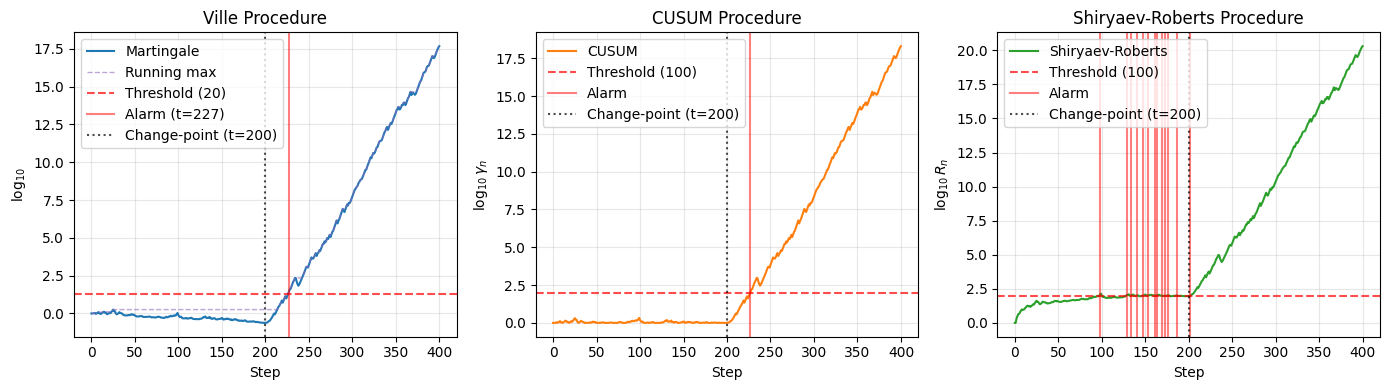

Ville: rejected=True at t=227
CUSUM γ=1993863689360077568.0, SR R=202919373232752787456.0
→ CUSUM and SR grow faster after the change-point.


In [18]:
from online_cp import SimpleJumper, CUSUMWrapper, ShiryaevRobertsWrapper, VilleWrapper
from online_cp.plotting import plot_detector

# Generate p-values: 200 from Uniform (exchangeable), then 200 from Beta(0.3, 1) (shift)
rng_cp = np.random.default_rng(42)
p_values = np.concatenate([
    rng_cp.uniform(size=200),
    rng_cp.beta(0.3, 1.0, size=200),
])

# Run three wrappers on the same p-values
ville = VilleWrapper(SimpleJumper(), threshold=20)
cusum = CUSUMWrapper(SimpleJumper())
sr = ShiryaevRobertsWrapper(SimpleJumper())

for p in p_values:
    ville.update(p)
    cusum.update(p)
    sr.update(p)

# Plot with plot_detector — one call per wrapper
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

plot_detector(ville, change_point=200, ax=axes[0])
plot_detector(cusum, threshold=100, change_point=200, ax=axes[1])
plot_detector(sr, threshold=100, change_point=200, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Ville: rejected={ville.rejected} at t={ville.rejection_time}")
print(f"CUSUM γ={cusum.gamma:.1f}, SR R={sr.R:.1f}")
print("→ CUSUM and SR grow faster after the change-point.")

### 5.5 Sleeper martingales

The **SleeperStayer** martingale (Algorithm 9.4, ALRW2) maintains a pool of "sleeper" experts that wake up at every time step, allowing it to detect change-points at *unknown* locations without knowing the shift timescale in advance.

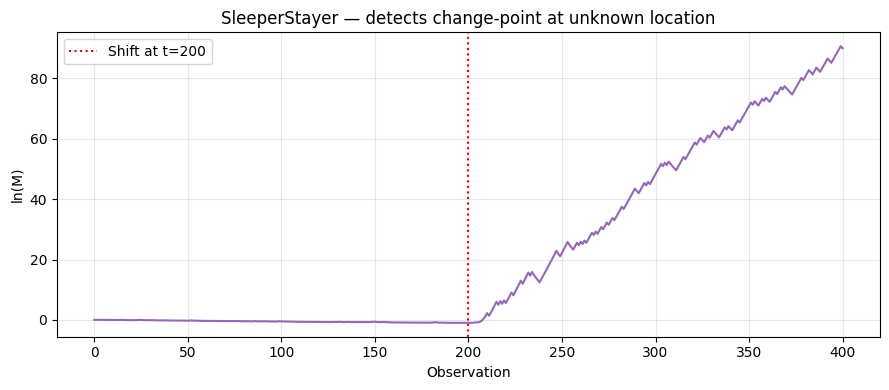

Final ln(M): 90.0
→ SleeperStayer grows rapidly after the shift, without knowing when it occurs.


In [19]:
from online_cp import SleeperStayer

# Same p-values as before: shift at t=200
mart_sleeper = SleeperStayer(R=0.01, G=5)

for p in p_values:
    mart_sleeper.update(p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(mart_sleeper.log_martingale_values, color="tab:purple", linewidth=1.5)
ax.axvline(200, color="red", linestyle=":", linewidth=1.5, label="Shift at t=200")
ax.set_xlabel("Observation")
ax.set_ylabel("ln(M)")
ax.set_title("SleeperStayer — detects change-point at unknown location")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final ln(M): {mart_sleeper.logM:.1f}")
print("→ SleeperStayer grows rapidly after the shift, without knowing when it occurs.")

**Martingale classes available:**
- Base: `PluginMartingale`, `SimpleMixtureMartingale`, `SimpleJumper`, `CompositeJumper`
- Change-point: `VilleWrapper`, `CUSUMWrapper`, `ShiryaevRobertsWrapper`, `SleeperStayer`, `SleeperDrifter`
- Betting strategies: `GaussianKDE`, `BetaKernel`, `BetaMoments`, `BetaMLE`, `PiecewiseConstantBetting`

See the [API docs](https://egonmedhatten.github.io/online-cp/api/martingale/) for full details.

---
## 6. Putting it into production

The `evaluate` module provides a clean interface for streaming evaluation without manual loops.

### 6.1 `progressive_val` — the standard evaluation loop

You've already seen this above. It runs test-then-train and updates metrics:

In [20]:
from online_cp.evaluate import iter_progressive_val

# iter_progressive_val yields periodic snapshots — great for learning curves
model_prod = ConformalRidgeRegressor(a=1.0)
model_prod.learn_initial_training_set(X_h[:50], y_h[:50])

metric_prod = ErrorRate() + IntervalWidth()
snapshots = list(iter_progressive_val(
    model_prod, X_h[50:], y_h[50:], epsilon=0.1, metric=metric_prod, step=50
))

print("Learning curve (checkpoints every 50 steps):")
for s in snapshots:
    print(f"  Step {s['step']:3d}: error={s['ErrorRate']:.3f}, width={s['IntervalWidth']:.2f}")

Learning curve (checkpoints every 50 steps):
  Step  50: error=0.080, width=2.52
  Step 100: error=0.100, width=2.32
  Step 150: error=0.100, width=2.31
  Step 200: error=0.090, width=2.27
  Step 250: error=0.100, width=2.24
  Step 300: error=0.107, width=2.23
  Step 350: error=0.111, width=2.23
  Step 400: error=0.130, width=2.25
  Step 450: error=0.136, width=2.26
  Step 500: error=0.132, width=2.27
  Step 550: error=0.122, width=2.28


### 6.2 Conditional learning

In practice, labels may arrive with delay or only for a subset of predictions. The `learn` parameter controls when the model updates:

In [21]:
# Simulate 50% label availability
model_cond = ConformalRidgeRegressor(a=1.0)
model_cond.learn_initial_training_set(X_h[:50], y_h[:50])

m_full = ErrorRate() + IntervalWidth()
m_half = ErrorRate() + IntervalWidth()

# Full learning
model_full = ConformalRidgeRegressor(a=1.0)
model_full.learn_initial_training_set(X_h[:50], y_h[:50])
progressive_val(model_full, X_h[50:300], y_h[50:300], epsilon=0.1, metric=m_full)

# 50% learning
progressive_val(
    model_cond, X_h[50:300], y_h[50:300], epsilon=0.1, metric=m_half,
    learn=lambda i, x, y: i % 2 == 0
)

print(f"100% labels: {m_full}")
print(f" 50% labels: {m_half}")
print(f"\n→ Coverage guarantee still holds! But intervals are wider with fewer labels.")

100% labels: ErrorRate: 0.1000
IntervalWidth: 2.2434
 50% labels: ErrorRate: 0.1000
IntervalWidth: 2.3605

→ Coverage guarantee still holds! But intervals are wider with fewer labels.


### 6.3 Composable metrics

Metrics combine with `+` and provide running statistics:

| Metric | For | Description |
|--------|-----|-------------|
| `ErrorRate` | All | Fraction outside prediction set |
| `IntervalWidth` | Regression | Average interval width |
| `WinklerScore` | Regression | Penalises width + miscoverage |
| `SetSize` | Classification | Average prediction set size |
| `ObservedFuzziness` | All | Calibration via p-values |
| `CRPS` | CPS | Continuous Ranked Probability Score |

---
## Summary

### API at a glance

```python
model = ConformalRidgeRegressor(a=1.0)
model.learn_initial_training_set(X_train, y_train)

interval = model.predict(x_new, epsilon=0.1)       # single level
result   = model.predict(x_new, epsilon=[...])     # multi-level
p        = model.compute_p_value(x_new, y_new)     # p-value
model.learn_one(x_new, y_new)                      # online update
```

### Available models

| Category | Classes |
|----------|--------|
| **Regressors** | `ConformalRidgeRegressor`, `KernelConformalRidgeRegressor`, `ConformalLassoRegressor`, `ConformalNearestNeighboursRegressor` |
| **Classifiers** | `ConformalNearestNeighboursClassifier`, `ConformalSupportVectorMachine` |
| **Venn Predictors** | `VennAbersPredictor` (ridge, k-NN, SVM scoring), `NearestNeighboursVennPredictor` (binary & multiclass) |
| **Mondrian** | `MondrianConformalRegressor`, `MondrianConformalClassifier` |
| **CPS** | `RidgePredictionMachine`, `KernelRidgePredictionMachine`, `NearestNeighboursPredictionMachine` |
| **Martingales** | `PluginMartingale`, `SimpleMixtureMartingale`, `SimpleJumper`, `CompositeJumper`, `SleeperStayer`, `SleeperDrifter` |
| **Detection Wrappers** | `VilleWrapper`, `CUSUMWrapper`, `ShiryaevRobertsWrapper` |
| **Kernels** | `GaussianKernel`, `LinearKernel`, `PolynomialKernel`, `PeriodicKernel` |

### Looking for Inductive (Split) Conformal Prediction?

This package focuses on **online** (transductive) conformal prediction. For **inductive** (split) conformal methods — where you have a fixed pre-trained model and a held-out calibration set — we recommend the [`crepes`](https://github.com/henrikbostrom/crepes) package.

### References

- Vovk, Gammerman, Shafer. *Algorithmic Learning in a Random World* (2nd ed). Springer, 2022.
- Lei. *Fast exact conformalization of the lasso using piecewise linear homotopy*. Biometrika, 2019.